In [ ]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from utils.utility import *
from utils.models_arch import *
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Stage 3: Fine-Tuning Classification Head

## Overview
This notebook trains a lightweight classifier head on top of frozen pretrained encoders.

**Strategy**: Transfer Learning with Frozen Backbones
```
Labeled Dataset (10,000 samples) → Split: 70% train, 15% val, 15% test
    ↓
Load pretrained Encoder1 (frozen)
Load pretrained Encoder2 (frozen)
    ↓
Forward pass: (sparse coords, features) → Encoder1 → Encoder2 → z(B,64)
    ↓
Train ONLY: Classification Head
    ↓
Classifier: (B,64) → MLP → (B,2) logits for binary classification
```

**Key Insight**:
- Encoders already learned good representations from 60k unlabeled samples
- Only fine-tune 2-layer MLP on top (much fewer parameters to optimize)
- Fast training (~12 epochs) with early stopping
- Avoids catastrophic forgetting of pretrained weights

In [ ]:
LABELLED_H5 = "data/Dataset_Specific_labelled.h5"
AE1_CKPT    = "models/ae1_trained.pth"
AE2_CKPT    = "models/ae2_trained.pth"

## Part 1: Load Pretrained Encoders

**Checkpoints**:
- `ae1_trained.pth`: Encoder1 weights from Stage 1 (60k unlabeled)
- `ae2_trained.pth`: Encoder2 weights from Stage 2 (60k latent)

**Freeze Strategy**:
```python
for p in encoder1.parameters():
    p.requires_grad = False
for p in encoder2.parameters():
    p.requires_grad = False
```
All encoder weights are frozen - no gradient updates during fine-tuning

**Dataset Split**:
- Total labeled: 10,000 samples
- Training: 7,000 (70%)
- Validation: 1,500 (15%)
- Test: 1,500 (15%)
- Reproducible split via `torch.Generator().manual_seed(42)`

In [6]:
full_dataset = H5LabelledDataset(LABELLED_H5)

n_total = len(full_dataset)
n_train = int(0.7 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

7000 1500 1500


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=labelled_sparse_collate,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=labelled_sparse_collate,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=labelled_sparse_collate,
    num_workers=0
)

In [8]:
ae1 = AutoEncoder1().to(device)
ae1.load_state_dict(torch.load(AE1_CKPT, map_location=device))
ae1.eval()

ae2 = AutoEncoder2().to(device)
ae2.load_state_dict(torch.load(AE2_CKPT, map_location=device))
ae2.eval()

print("Loaded pretrained AE1 and AE2.")

Loaded pretrained AE1 and AE2.


/tmp/ipykernel_6961/2032248579.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ae1.load_state_dict(torch.load(AE1_CKPT, map_location=device))
/tmp/ipykernel_6961/2032248

In [9]:
model = SparseEventClassifier(ae1.encoder, ae2.encoder).to(device)
print(model)

SparseEventClassifier(
  (encoder1): Encoder1(
    (stage1): SparseVGGStage(
      (blocks): ModuleList(
        (0-2): 3 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x2()
    )
    (stage2): SparseVGGStage(
      (blocks): ModuleList(
        (0-1): 2 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x2()
    )
  )
  (encoder2): Encoder2(
    (stage): SparseVGGStage(
      (blocks): ModuleList(
        (0-2): 3 x SparseVSCBlockRulebook(
          (vsc): VSC3x3Rulebook()
          (bn): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
        )
      )
      (pool): SparseMaxPool2x

In [10]:
for p in model.encoder1.parameters():
    p.requires_grad = False

for p in model.encoder2.parameters():
    p.requires_grad = False

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

## Part 2: Classifier Head Architecture

**SparseEventClassifier**:
```
Input: (coords, feats) - sparse representation
    ↓
Encoder1: (N,8) → (N,32) with pooling
    ↓
Encoder2: (N,32) → (N,64) with pooling
    ↓
Global Mean Pool: Aggregate → (B,64)
    ↓
Classification Head (trainable):
    Linear(64, 64)
    ReLU
    Dropout(p=0.2)
    Linear(64, 2)
    ↓
Output: (B,2) logits for binary classification
```

**Why this structure?**
- Encoder1 + Encoder2: Transfer learned hierarchical features
- Global pooling: Permutation-invariant aggregation
- MLP head: Lightweight (64→64→2), few parameters
- Dropout: Regularization to prevent overfitting on small labeled set

**Training Configuration**:
- **Loss**: CrossEntropyLoss
- **Optimizer**: Adam (lr=1e-3) - updates ONLY classification head
- **Batch size**: 4 samples
- **Gradient accumulation**: 2 steps → effective batch=8
- **Max epochs**: 50 with early stopping patience=3

**Early Stopping**:
- Monitor validation error
- Stop if no improvement for 3 consecutive epochs
- Save best model checkpoint

In [ ]:
num_epochs = 50
accum_steps = 2

best_val_err = float("inf")
patience = 3
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_errs, val_errs = [], []

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.head.parameters(), lr=1e-3)

for epoch in range(num_epochs):

    model.train()
    optimizer.zero_grad()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for step, batch in enumerate(train_loader):

        coords = batch["coords"].to(device)
        feats = batch["feats"].to(device)
        labels = batch["labels"].to(device)

        logits = model(coords, feats)

        loss = criterion(logits, labels)

        (loss / accum_steps).backward()

        if (step + 1) % accum_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        preds = logits.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    if len(train_loader) % accum_steps != 0:
        optimizer.step()
        optimizer.zero_grad()

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    train_err = 1.0 - train_acc


    model.eval()

    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for batch in val_loader:

            coords = batch["coords"].to(device)
            feats = batch["feats"].to(device)
            labels = batch["labels"].to(device)

            logits = model(coords, feats)

            loss = criterion(logits, labels)

            preds = logits.argmax(dim=1)

            val_loss_sum += loss.item() * labels.size(0)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    val_err = 1.0 - val_acc

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_errs.append(train_err)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_errs.append(val_err)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} Acc {val_acc:.4f}"
    )


    if val_err < best_val_err:

        best_val_err = val_err
        epochs_no_improve = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_err": val_err,
            },
            "models/best_sparse_classifier.pth"
        )

        print("Saved best model")

    else:

        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

Epoch 1/50 | Train Loss 0.5898 Acc 0.7013 | Val Loss 0.5142 Acc 0.7647
Saved best model
Epoch 2/50 | Train Loss 0.5299 Acc 0.7496 | Val Loss 0.4998 Acc 0.7707
Saved best model
Epoch 3/50 | Train Loss 0.5174 Acc 0.7557 | Val Loss 0.4818 Acc 0.7760
Saved best model
Epoch 4/50 | Train Loss 0.5165 Acc 0.7510 | Val Loss 0.5096 Acc 0.7507
No improvement for 1 epoch(s)
Epoch 5/50 | Train Loss 0.5060 Acc 0.7634 | Val Loss 0.4872 Acc 0.7687
No improvement for 2 epoch(s)
Epoch 6/50 | Train Loss 0.5027 Acc 0.7606 | Val Loss 0.4711 Acc 0.7873
Saved best model
Epoch 7/50 | Train Loss 0.5023 Acc 0.7663 | Val Loss 0.4786 Acc 0.7767
No improvement for 1 epoch(s)
Epoch 8/50 | Train Loss 0.4985 Acc 0.7686 | Val Loss 0.4620 Acc 0.7907
Saved best model
Epoch 9/50 | Train Loss 0.4947 Acc 0.7697 | Val Loss 0.4617 Acc 0.7913
Saved best model
Epoch 10/50 | Train Loss 0.5016 Acc 0.7624 | Val Loss 0.4802 Acc 0.7753
No improvement for 1 epoch(s)
Epoch 11/50 | Train Loss 0.4945 Acc 0.7727 | Val Loss 0.4860 Acc 0.

In [15]:
model.eval()

test_loss_sum = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch in test_loader:
        coords = batch["coords"].to(device)
        feats = batch["feats"].to(device)
        labels = batch["labels"].to(device)

        logits = model(coords, feats)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)

        test_loss_sum += loss.item() * labels.size(0)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

test_loss = test_loss_sum / test_total
test_acc = test_correct / test_total
test_err = 1.0 - test_acc

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")
print(f"Test Err : {test_err:.4f}")

Test Loss: 0.4552
Test Acc : 0.7953
Test Err : 0.2047


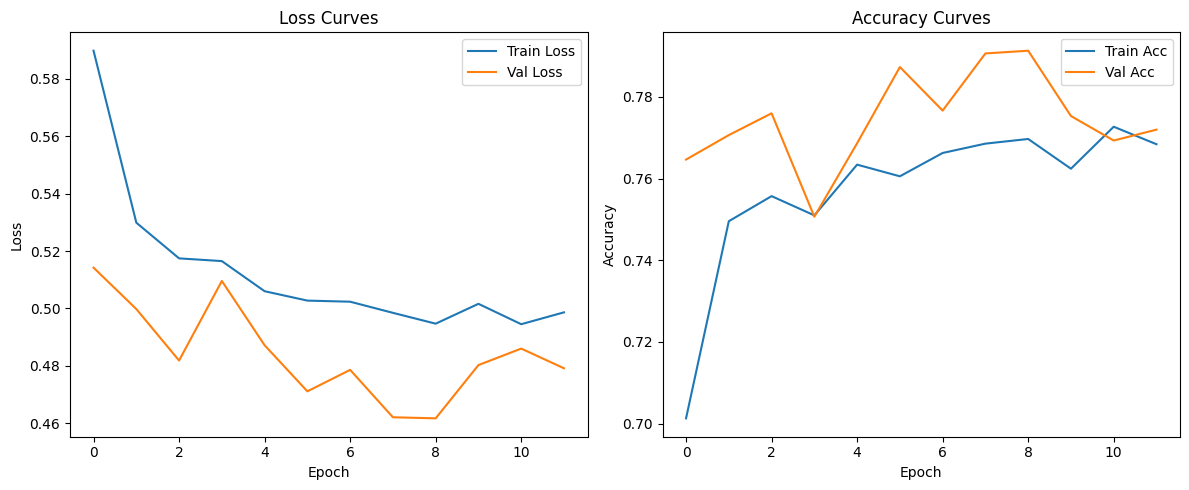

In [16]:
from matplotlib import pyplot as plt
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.tight_layout()
plt.show()